# FairLens — Notebook 2: Bias Detection & RL Correction Layer
**Purpose:** Load the pre-trained classifier, detect bias across all protected attributes, fix it with RL on only the biased attributes, and show a full before/after evaluation.  
This notebook never retrains the model — it only wraps around it.

---
### How to use
1. Run Notebook 1 first to generate saved files
2. Set `ASSET_DIR` to wherever Notebook 1 saved its files
3. Run all cells top to bottom

### How splits are used in this notebook
| Split | Role in NB2 |
|-------|-------------|
| **TRAIN** | RL agent training environment — pre-SMOTE real patients, all 4 attr arrays |
| **VAL** | Recall floor computation — sets minimum recall the RL agent must preserve |
| **TEST** | Bias detection + final evaluation — never used until Stage 2 |

### Pipeline
```
STAGE 1  Load model + all 3 splits + all 4 protected attribute arrays
STAGE 2  Bias Detection  <- check all 4 attrs on TEST set -> biased_attrs list
STAGE 3  RL Correction   <- runs only if biased_attrs is non-empty
                            trains on TRAIN, uses VAL for recall floor
STAGE 4  Evaluation      <- before/after comparison on TEST, all 4 attrs
```

## STAGE 1 — Setup & Load Saved Assets

In [1]:
import subprocess, sys
pkgs = ['scikit-learn','numpy','pandas','matplotlib','seaborn','joblib','imbalanced-learn']
print('Checking packages...')
r = subprocess.run([sys.executable,'-m','pip','install','--quiet']+pkgs,
                   capture_output=True, text=True)
print('Ready.' if r.returncode==0 else r.stderr[-300:])

Checking packages...
Ready.


In [2]:
import os, json, warnings, random
from collections import defaultdict
import numpy  as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, recall_score, f1_score,
    precision_score, roc_auc_score)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi':130, 'axes.spines.top':False,
    'axes.spines.right':False, 'font.family':'DejaVu Sans',
    'axes.titlesize':12, 'axes.labelsize':11, 'axes.titleweight':'bold'})

C_BEFORE  = '#E65100'
C_AFTER   = '#2E7D32'
C_FAIR    = '#2E7D32'
C_BIASED  = '#C62828'
C_NEUTRAL = '#607D8B'
# Palette for up to 4 protected attribute groups
GROUP_COLORS = ['#4A90D9','#E05C97','#F5A623','#7ED321','#9B59B6','#1ABC9C']

print('Imports OK.')

Imports OK.


In [3]:
# =============================================================================
# SET THIS PATH to wherever Notebook 1 saved its files
# =============================================================================
ASSET_DIR = 'fairlens_assets'
# =============================================================================

print(f'Loading assets from: {ASSET_DIR}')
assert os.path.exists(ASSET_DIR), f'Directory not found: {ASSET_DIR}. Run Notebook 1 first.'

# Model
model = joblib.load(f'{ASSET_DIR}/rf_model.pkl')
print('Model loaded.')

# Config
with open(f'{ASSET_DIR}/config.json') as f:
    config = json.load(f)

best_thresh        = config['best_threshold']
imbalance_ratio    = config['imbalance_ratio']
feature_cols       = config['feature_cols']
FAIRNESS_THRESHOLD = config['fairness_threshold']
PROTECTED_ATTRS    = config['protected_attrs']        # [gender, ever_married, Residence_type, age_group]
raw_maps           = config['attr_label_maps']

# Reconstruct label maps: {int_code -> human_label}
attr_label_maps = {
    attr: {int(k): v for k, v in raw_maps[attr].items()}
    for attr in PROTECTED_ATTRS
}

# ── Feature arrays (3 splits) ─────────────────────────────────────────────
X_train = np.load(f'{ASSET_DIR}/X_train.npy')   # pre-SMOTE — real patients for RL
y_train = np.load(f'{ASSET_DIR}/y_train.npy')
X_val   = np.load(f'{ASSET_DIR}/X_val.npy')
y_val   = np.load(f'{ASSET_DIR}/y_val.npy')
X_test  = np.load(f'{ASSET_DIR}/X_test.npy')
y_test  = np.load(f'{ASSET_DIR}/y_test.npy')

# ── Protected attribute arrays (3 splits × 4 attrs) ───────────────────────
split_attrs = {}
for split_name in ['train', 'val', 'test']:
    split_attrs[split_name] = {}
    for attr in PROTECTED_ATTRS:
        path = f'{ASSET_DIR}/{split_name}_{attr}.npy'
        split_attrs[split_name][attr] = np.load(path)

print(f'\nSplit sizes:')
print(f'  TRAIN : {len(y_train):,} patients  |  strokes: {y_train.sum()}')
print(f'  VAL   : {len(y_val):,} patients  |  strokes: {y_val.sum()}')
print(f'  TEST  : {len(y_test):,} patients  |  strokes: {y_test.sum()}')
print(f'\nProtected attributes  : {PROTECTED_ATTRS}')
print(f'Fairness threshold    : {FAIRNESS_THRESHOLD:.0%}')
print(f'Decision threshold    : {best_thresh:.3f}')
print(f'Class imbalance       : {imbalance_ratio:.1f}:1  (accuracy is NOT used as primary metric)')

Loading assets from: fairlens_assets
Model loaded.

Split sizes:
  TRAIN : 30,372 patients  |  strokes: 548
  VAL   : 4,339 patients  |  strokes: 78
  TEST  : 8,678 patients  |  strokes: 157

Protected attributes  : ['gender', 'ever_married', 'Residence_type', 'age_group']
Fairness threshold    : 5%
Decision threshold    : 0.060
Class imbalance       : 54.4:1  (accuracy is NOT used as primary metric)


In [4]:
# ── Get model probabilities for all 3 splits ──────────────────────────────
proba_train = model.predict_proba(X_train)[:, 1]   # used by RL env
proba_val   = model.predict_proba(X_val)[:,   1]   # used for recall floor
proba_test  = model.predict_proba(X_test)[:,  1]   # used for evaluation

y_pred_base = (proba_test >= best_thresh).astype(int)

def fbeta_score(y_true, y_pred, beta=2.0):
    tp=int(((y_pred==1)&(y_true==1)).sum())
    fp=int(((y_pred==1)&(y_true==0)).sum())
    fn=int(((y_pred==0)&(y_true==1)).sum())
    p=tp/(tp+fp+1e-9); r=tp/(tp+fn+1e-9); b2=beta**2
    return (1+b2)*p*r/(b2*p+r+1e-9)

def gmean_score(y_true, y_pred):
    cm=confusion_matrix(y_true,y_pred); tn,fp,fn,tp=cm.ravel()
    return np.sqrt((tp/(tp+fn+1e-9))*(tn/(tn+fp+1e-9)))

recall_base    = recall_score(y_test, y_pred_base, pos_label=1)
precision_base = precision_score(y_test, y_pred_base, pos_label=1, zero_division=0)
f1_base        = f1_score(y_test, y_pred_base, pos_label=1)
f2_base        = fbeta_score(y_test, y_pred_base, beta=2.0)
gmean_base     = gmean_score(y_test, y_pred_base)
roc_base       = roc_auc_score(y_test, proba_test)
cm_base        = confusion_matrix(y_test, y_pred_base)
tn_b,fp_b,fn_b,tp_b = cm_base.ravel()

print('Base model on TEST set:')
print(f'  Recall    : {recall_base:.4f}  (caught {tp_b}/{tp_b+fn_b} strokes)')
print(f'  Precision : {precision_base:.4f}')
print(f'  F1-stroke : {f1_base:.4f}')
print(f'  F2-stroke : {f2_base:.4f}  <- primary metric')
print(f'  G-Mean    : {gmean_base:.4f}')
print(f'  ROC-AUC   : {roc_base:.4f}')
print('\nAll 3 splits loaded. Proceeding to Stage 2.')

Base model on TEST set:
  Recall    : 0.2994  (caught 47/157 strokes)
  Precision : 0.0649
  F1-stroke : 0.1067
  F2-stroke : 0.1738  <- primary metric
  G-Mean    : 0.5250
  ROC-AUC   : 0.7999

All 3 splits loaded. Proceeding to Stage 2.


## STAGE 2 — Multi-Attribute Bias Detection

Bias is checked on the **TEST set** for all 4 protected attributes.  
Two fairness metrics are computed per attribute:

| Metric | What it measures | Biased if... |
|--------|------------------|--------------|
| **Demographic Parity (DP)** | Are all groups predicted stroke at equal rates? | Gap > 5% |
| **Equalized Odds (EO)** | Among real stroke patients, are all groups detected equally? | Gap > 5% |

RL only runs for attributes that fail at least one of these checks.

In [5]:
def compute_attr_fairness(y_pred, y_true, attr_arr, label_map, attr_name='', verbose=True):
    """Compute DP and EO fairness gaps for one protected attribute.

    Returns a dict with:
      dp_gap, eo_gap, dp_fair, eo_fair,
      stats  -> {human_label: {n, n_strokes, pos_rate, tpr}},
      dp_high -> group with highest positive prediction rate,
      eo_low  -> group with lowest stroke detection rate
    """
    y_pred    = np.array(y_pred, dtype=int)
    y_true    = np.array(y_true, dtype=int)
    attr_arr  = np.array(attr_arr, dtype=int)
    groups    = np.unique(attr_arr)
    stats     = {}
    for g in groups:
        mask   = attr_arr == g
        preds_g = y_pred[mask]
        true_g  = y_true[mask]
        n_pos   = int(true_g.sum())
        tpr     = float(((preds_g==1)&(true_g==1)).sum() / n_pos) if n_pos > 0 else 0.0
        lbl     = label_map.get(int(g), str(g))
        stats[lbl] = {
            'n'          : int(mask.sum()),
            'n_strokes'  : n_pos,
            'n_predicted': int(preds_g.sum()),
            'pos_rate'   : float(preds_g.mean()),
            'tpr'        : tpr
        }
    pos_rates = [s['pos_rate'] for s in stats.values()]
    tprs      = [s['tpr']      for s in stats.values()]
    dp_gap    = max(pos_rates) - min(pos_rates)
    eo_gap    = max(tprs)      - min(tprs)
    dp_high   = max(stats, key=lambda g: stats[g]['pos_rate'])
    eo_low    = min(stats, key=lambda g: stats[g]['tpr'])
    result = {
        'dp_gap' : dp_gap,
        'eo_gap' : eo_gap,
        'dp_fair': dp_gap <= FAIRNESS_THRESHOLD,
        'eo_fair': eo_gap <= FAIRNESS_THRESHOLD,
        'stats'  : stats,
        'dp_high': dp_high,
        'eo_low' : eo_low
    }
    if verbose:
        w = '=' * 65
        print(f'\n{w}')
        print(f'  FAIRNESS: {attr_name.upper()}')
        print(w)
        print(f"  {'Group':<16} {'Patients':>9} {'Strokes':>8} {'Pred rate':>10} {'Detection':>10}")
        print('  ' + '-' * 56)
        for lbl2, s in stats.items():
            print(f"  {lbl2:<16} {s['n']:>9,} {s['n_strokes']:>8} "
                  f"{s['pos_rate']:>9.1%} {s['tpr']:>10.1%}")
        print('  ' + '-' * 56)
        dp_sym = '[OK]' if result['dp_fair'] else '[!!]'
        eo_sym = '[OK]' if result['eo_fair'] else '[!!]'
        print(f"  {dp_sym} Demographic Parity gap : {dp_gap:.1%}  ->  {'FAIR  ' if result['dp_fair'] else 'BIASED'}")
        if not result['dp_fair']:
            print(f"       '{dp_high}' predicted stroke {dp_gap:.1%} more often")
        print(f"  {eo_sym} Equalized Odds gap     : {eo_gap:.1%}  ->  {'FAIR  ' if result['eo_fair'] else 'BIASED'}")
        if not result['eo_fair']:
            print(f"       '{eo_low}' has strokes detected {eo_gap:.1%} less often")
    return result

print('Fairness detection function defined.')

Fairness detection function defined.


In [6]:
print('=' * 65)
print('  RUNNING BIAS DETECTION — ALL PROTECTED ATTRIBUTES (TEST SET)')
print('=' * 65)

base_fairness_all = {}   # attr -> fairness result dict
biased_attrs      = []   # attrs that fail at least one metric

for attr in PROTECTED_ATTRS:
    result = compute_attr_fairness(
        y_pred    = y_pred_base,
        y_true    = y_test,
        attr_arr  = split_attrs['test'][attr],
        label_map = attr_label_maps[attr],
        attr_name = attr,
        verbose   = True
    )
    base_fairness_all[attr] = result
    if not result['dp_fair'] or not result['eo_fair']:
        biased_attrs.append(attr)

# ── Verdict ───────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  BIAS VERDICT SUMMARY')
print('=' * 65)
print(f"  {'Attribute':<20} {'DP gap':>8} {'DP':>8} {'EO gap':>8} {'EO':>8} {'Overall':>10}")
print('  ' + '-' * 64)
for attr in PROTECTED_ATTRS:
    r = base_fairness_all[attr]
    overall = 'BIASED' if (not r['dp_fair'] or not r['eo_fair']) else 'FAIR'
    print(f"  {attr:<20} {r['dp_gap']:>7.1%} {'FAIR' if r['dp_fair'] else 'BIASED':>8} "
          f"{r['eo_gap']:>7.1%} {'FAIR' if r['eo_fair'] else 'BIASED':>8} {overall:>10}")
print('  ' + '-' * 64)

if biased_attrs:
    print(f'\n  BIASED ATTRIBUTES : {biased_attrs}')
    print(f'  -> RL correction will run on: {biased_attrs}')
    print(f'  -> Skipped (already fair)   : {[a for a in PROTECTED_ATTRS if a not in biased_attrs]}')
else:
    print('\n  ALL ATTRIBUTES ARE FAIR — RL correction will not run.')

  RUNNING BIAS DETECTION — ALL PROTECTED ATTRIBUTES (TEST SET)

  FAIRNESS: GENDER
  Group             Patients  Strokes  Pred rate  Detection
  --------------------------------------------------------
  Female               5,149       89      7.5%      29.2%
  Male                 3,529       68      9.5%      30.9%
  --------------------------------------------------------
  [OK] Demographic Parity gap : 2.0%  ->  FAIR  
  [OK] Equalized Odds gap     : 1.7%  ->  FAIR  

  FAIRNESS: EVER_MARRIED
  Group             Patients  Strokes  Pred rate  Detection
  --------------------------------------------------------
  No                   3,087       19      2.4%      31.6%
  Yes                  5,591      138     11.6%      29.7%
  --------------------------------------------------------
  [!!] Demographic Parity gap : 9.3%  ->  BIASED
       'Yes' predicted stroke 9.3% more often
  [OK] Equalized Odds gap     : 1.9%  ->  FAIR  

  FAIRNESS: RESIDENCE_TYPE
  Group             Patients 

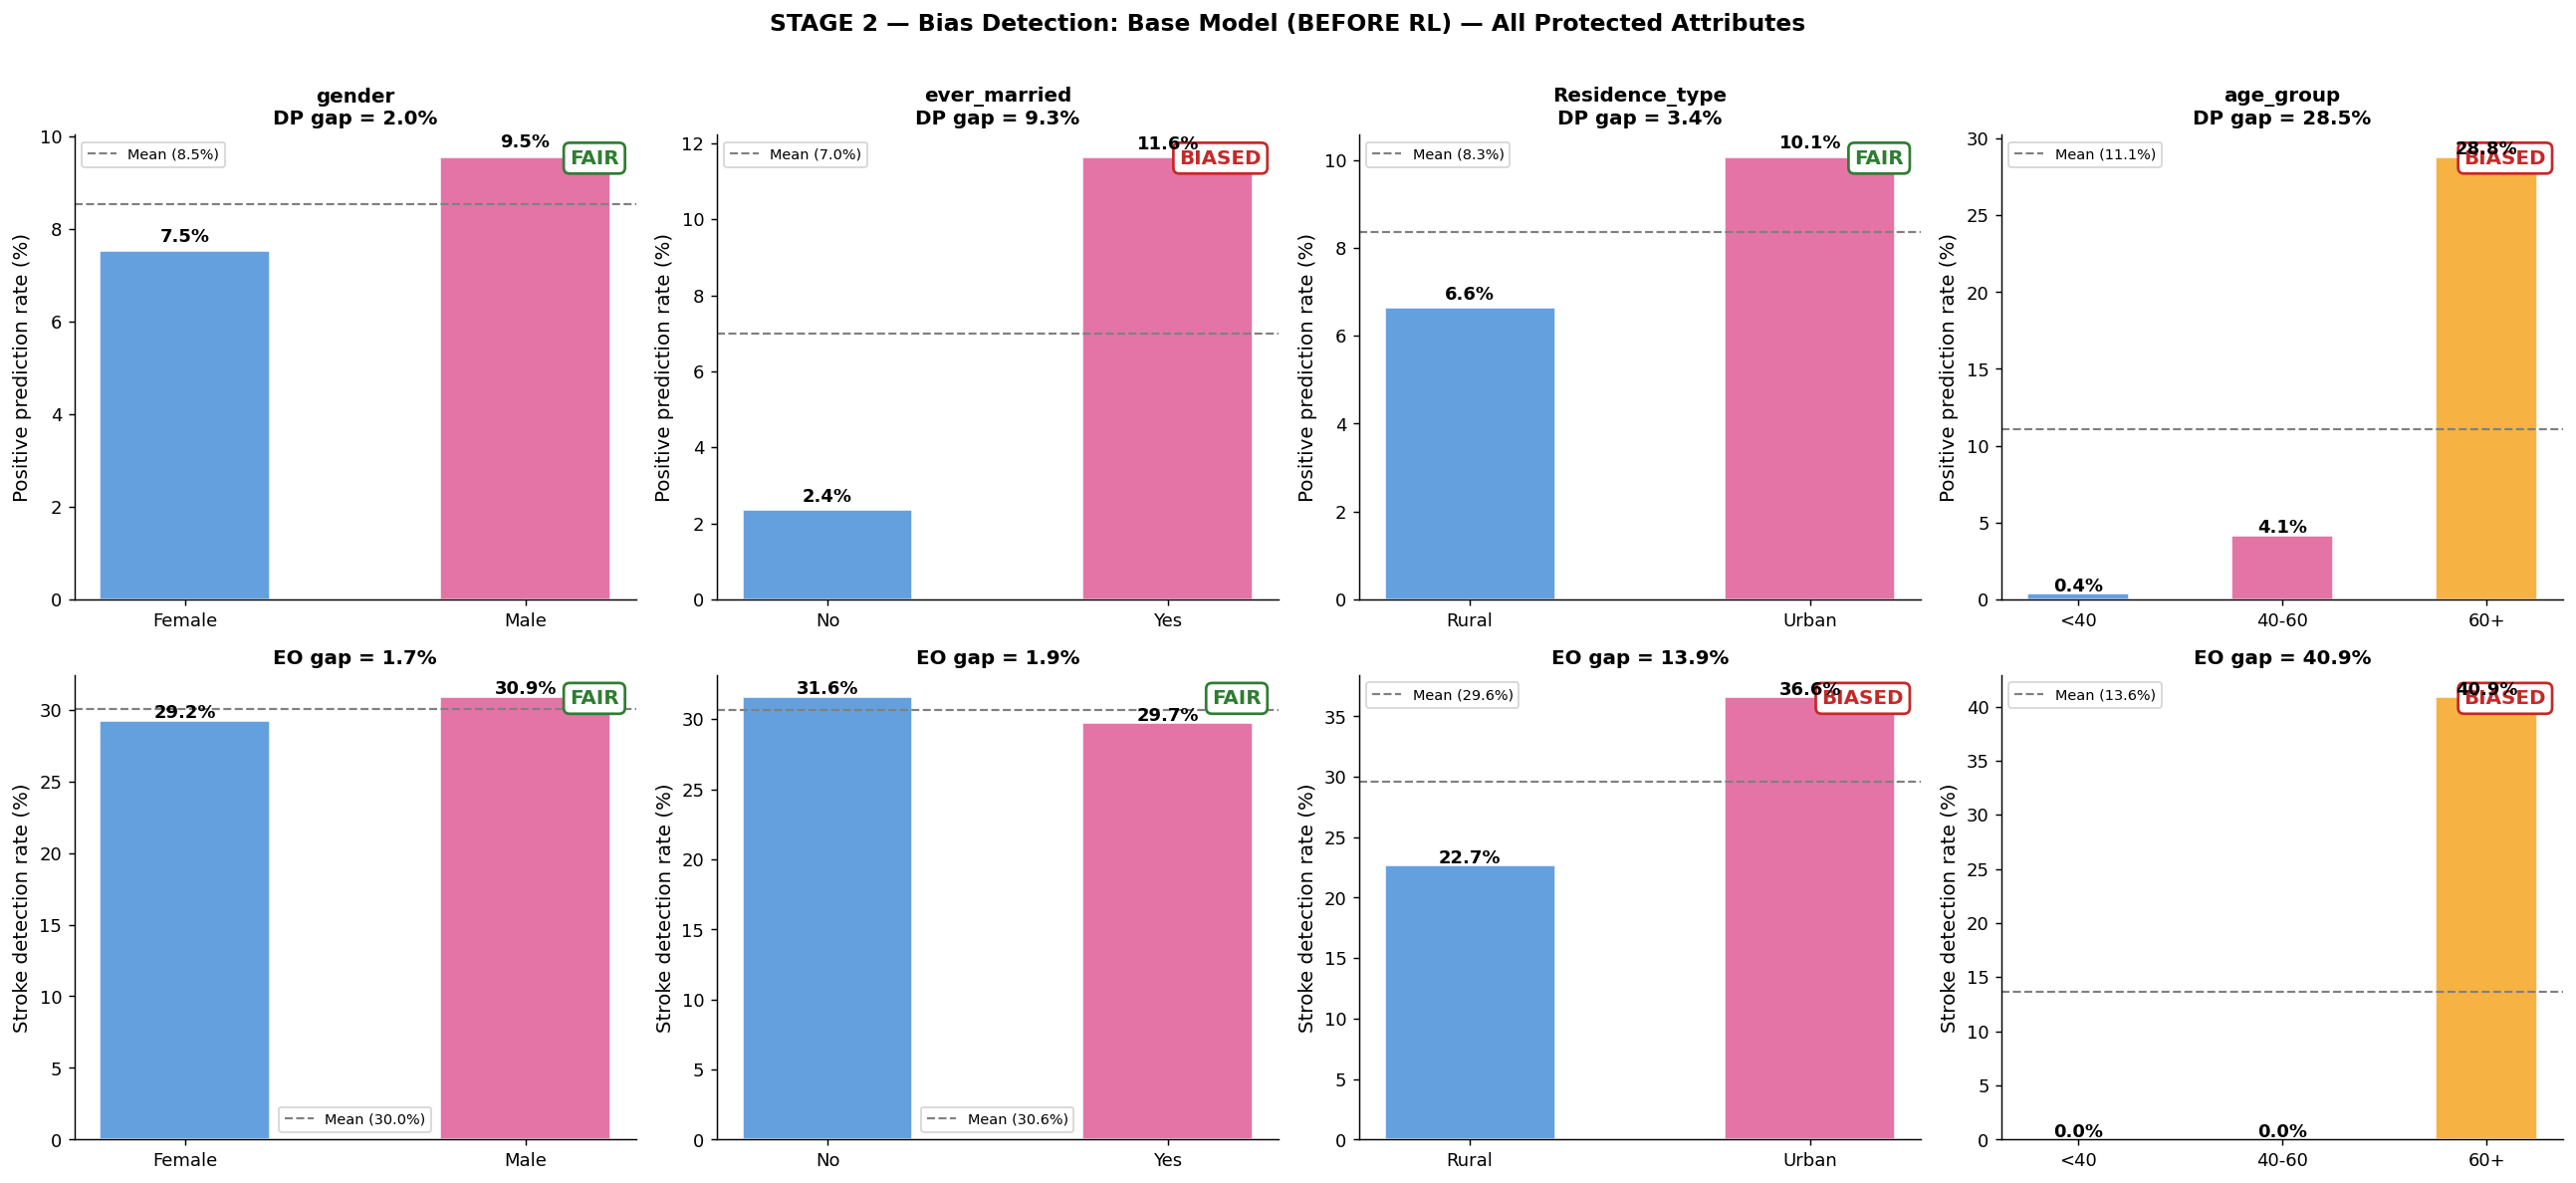

Figure 1 saved.


In [7]:
# ── Figure 1: Bias detection overview — one panel per protected attribute ─
n_attrs = len(PROTECTED_ATTRS)
fig, axes = plt.subplots(2, n_attrs, figsize=(5*n_attrs, 9))
fig.suptitle('STAGE 2 — Bias Detection: Base Model (BEFORE RL) — All Protected Attributes',
             fontweight='bold', fontsize=13, y=1.01)

for col, attr in enumerate(PROTECTED_ATTRS):
    r       = base_fairness_all[attr]
    stats   = r['stats']
    labels  = list(stats.keys())
    colors  = GROUP_COLORS[:len(labels)]
    x       = np.arange(len(labels))

    # Row 0: DP (positive prediction rate)
    ax_dp = axes[0, col]
    vals_dp = [stats[g]['pos_rate']*100 for g in labels]
    bars = ax_dp.bar(labels, vals_dp, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax_dp.axhline(np.mean(vals_dp), color='grey', linestyle='--', linewidth=1.2,
                  label=f'Mean ({np.mean(vals_dp):.1f}%)')
    gap_dp = r['dp_gap']*100; fair_dp = r['dp_fair']
    vc = C_FAIR if fair_dp else C_BIASED; vl = 'FAIR' if fair_dp else 'BIASED'
    ax_dp.set_title(f'{attr}\nDP gap = {gap_dp:.1f}%', fontsize=11)
    ax_dp.set_ylabel('Positive prediction rate (%)')
    ax_dp.text(0.97, 0.97, vl, transform=ax_dp.transAxes, fontsize=11, fontweight='bold',
               color=vc, ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=vc, linewidth=1.5))
    for bar, v in zip(bars, vals_dp):
        ax_dp.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax_dp.legend(fontsize=8)

    # Row 1: EO (stroke detection rate / TPR)
    ax_eo = axes[1, col]
    vals_eo = [stats[g]['tpr']*100 for g in labels]
    bars2 = ax_eo.bar(labels, vals_eo, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax_eo.axhline(np.mean(vals_eo), color='grey', linestyle='--', linewidth=1.2,
                  label=f'Mean ({np.mean(vals_eo):.1f}%)')
    gap_eo = r['eo_gap']*100; fair_eo = r['eo_fair']
    vc2 = C_FAIR if fair_eo else C_BIASED; vl2 = 'FAIR' if fair_eo else 'BIASED'
    ax_eo.set_title(f'EO gap = {gap_eo:.1f}%', fontsize=11)
    ax_eo.set_ylabel('Stroke detection rate (%)')
    ax_eo.text(0.97, 0.97, vl2, transform=ax_eo.transAxes, fontsize=11, fontweight='bold',
               color=vc2, ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=vc2, linewidth=1.5))
    for bar, v in zip(bars2, vals_eo):
        ax_eo.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax_eo.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{ASSET_DIR}/fig1_bias_detection.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## STAGE 3 — RL Correction Agent

**Trigger:** Runs only if `biased_attrs` is non-empty (Stage 2 found at least one biased attribute).  
**Training data:** TRAIN split (pre-SMOTE, real patients). Protected attr arrays for all biased attributes.  
**Recall floor:** Computed from VAL split — the agent is penalised if recall drops below this.  
**Output:** A dict of `(attr, group_code) -> threshold` for each biased group.  
**Threshold application:** Each patient's final threshold = minimum across all their biased-group thresholds (strictest wins — in healthcare, easier flagging is safer).

**Reward:** `α × (DP improvement + 2×EO improvement) − β × (1−F1) − γ × max(0, recall_floor − recall)`  
EO is weighted 2× because missing a stroke is worse than a false alarm.

In [8]:
class FairnessEnv:
    """Multi-attribute fairness RL environment.

    Maintains a threshold per (attr, group_code) pair.
    At inference, each patient gets the minimum threshold across all
    their group memberships (strictest = easiest to flag = safest).
    """
    ALPHA    = 0.50    # fairness reward weight
    BETA     = 0.30    # F1 preservation penalty weight
    GAMMA    = 0.20    # recall floor penalty weight
    DELTAS   = [-0.10, -0.05, -0.02, -0.01, 0.0, +0.01, +0.02, +0.05, +0.10]
    N_ACTIONS = len(DELTAS)
    N_BUCKETS = 5

    def __init__(self, proba, y_true, attrs_dict, base_threshold, recall_floor=0.0):
        """
        attrs_dict : {attr_name: numpy_array_of_group_codes}
                     Only includes biased attributes.
        """
        self.proba        = np.array(proba, dtype=float)
        self.y_true       = np.array(y_true, dtype=int)
        self.attrs_dict   = {k: np.array(v, dtype=int) for k, v in attrs_dict.items()}
        self.base_thresh  = float(base_threshold)
        self.recall_floor = min(float(recall_floor), 0.80)
        # Unique groups per attribute
        self.attr_groups  = {attr: np.unique(arr) for attr, arr in self.attrs_dict.items()}
        # One threshold slot per (attr, group_code)
        self.thresholds   = {
            (attr, int(g)): self.base_thresh
            for attr, groups in self.attr_groups.items()
            for g in groups
        }
        # All (attr, group) pairs for episode iteration
        self.all_pairs = list(self.thresholds.keys())

    def reset(self):
        self.thresholds = {k: self.base_thresh for k in self.thresholds}

    def _apply(self):
        """Predict with per-(attr,group) thresholds.
        Each patient gets the minimum (strictest) threshold across memberships."""
        patient_t = np.full(len(self.proba), self.base_thresh, dtype=float)
        for attr, arr in self.attrs_dict.items():
            for g in self.attr_groups[attr]:
                t    = float(np.clip(self.thresholds[(attr, int(g))], 0.05, 0.95))
                mask = arr == g
                patient_t[mask] = np.minimum(patient_t[mask], t)
        return (self.proba >= patient_t).astype(int)

    def _tpr(self, y_pred, attr, g):
        mask  = self.attrs_dict[attr] == g
        n_pos = self.y_true[mask].sum()
        if n_pos == 0: return 0.0
        return float(((y_pred[mask]==1) & (self.y_true[mask]==1)).sum() / n_pos)

    def _pos_rate(self, y_pred, attr, g):
        mask = self.attrs_dict[attr] == g
        return float(y_pred[mask].mean())

    def _attr_gaps(self, y_pred):
        """Returns {attr: {'dp': float, 'eo': float}} for all biased attrs."""
        gaps = {}
        for attr, groups in self.attr_groups.items():
            tprs = [self._tpr(y_pred, attr, g)      for g in groups]
            prs  = [self._pos_rate(y_pred, attr, g) for g in groups]
            gaps[attr] = {'eo': max(tprs)-min(tprs), 'dp': max(prs)-min(prs)}
        return gaps

    def _metrics(self):
        y_pred  = self._apply()
        f1      = f1_score(self.y_true, y_pred, pos_label=1, zero_division=0)
        rec     = recall_score(self.y_true, y_pred, pos_label=1, zero_division=0)
        gaps    = self._attr_gaps(y_pred)
        avg_dp  = np.mean([v['dp'] for v in gaps.values()])
        avg_eo  = np.mean([v['eo'] for v in gaps.values()])
        return y_pred, f1, rec, avg_eo, avg_dp, gaps

    def _disc(self, eo, dp, f1):
        """Discretise continuous signals into bucket indices for Q-table state."""
        eb = min(int(eo / 0.2 * self.N_BUCKETS), self.N_BUCKETS - 1)
        db = min(int(dp / 0.2 * self.N_BUCKETS), self.N_BUCKETS - 1)
        fb = min(int(f1 * self.N_BUCKETS), self.N_BUCKETS - 1)
        return eb, db, fb

    def get_state(self, attr, group):
        """State encodes which (attr, group) is being adjusted + global fairness + F1."""
        _, f1, _, eo, dp, _ = self._metrics()
        eb, db, fb = self._disc(eo, dp, f1)
        return (attr, int(group), eb, db, fb)

    def step(self, attr, group, action_idx):
        _, _, _, eo_b, dp_b, _ = self._metrics()
        delta = self.DELTAS[action_idx]
        key   = (attr, int(group))
        self.thresholds[key] = float(np.clip(self.thresholds[key] + delta, 0.05, 0.95))
        _, f1, rec, eo_a, dp_a, _ = self._metrics()
        dp_imp = dp_b - dp_a
        eo_imp = eo_b - eo_a
        # EO weighted 2x — detecting strokes matters more than over-flagging
        reward = (self.ALPHA * (dp_imp + 2.0 * eo_imp)
                  - self.BETA  * (1.0 - f1)
                  - self.GAMMA * max(0.0, self.recall_floor - rec))
        return self.get_state(attr, group), reward, f1, rec, eo_a, dp_a

print('FairnessEnv defined.')
print(f'  Actions  : {FairnessEnv.DELTAS}')
print(f'  EO weighted 2x in reward — missing strokes is costlier than over-prediction')

FairnessEnv defined.
  Actions  : [-0.1, -0.05, -0.02, -0.01, 0.0, 0.01, 0.02, 0.05, 0.1]
  EO weighted 2x in reward — missing strokes is costlier than over-prediction


In [9]:
class QLearningAgent:
    def __init__(self, n_actions, lr=0.15, gamma=0.92,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.994):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table       = defaultdict(lambda: np.zeros(n_actions))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def learn(self, state, action, reward, next_state):
        pred   = self.q_table[state][action]
        target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.lr * (target - pred)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print('QLearningAgent defined.')

QLearningAgent defined.


In [10]:
if not biased_attrs:
    # ── No bias found — skip RL entirely ─────────────────────────────────
    print('No bias detected across any protected attribute.')
    print('RL agent skipped. Base model predictions will be used as final.')
    best_thresholds = {}     # empty — apply_thresholds will fall back to base_thresh
    N_EPISODES = 0
    history    = defaultdict(list)

else:
    # ── Prepare RL training environment ──────────────────────────────────
    N_EPISODES = 3000

    # Recall floor from VAL set (RL cannot drop recall below this)
    y_pred_val_base = (proba_val >= best_thresh).astype(int)
    recall_floor    = recall_score(y_val, y_pred_val_base, pos_label=1, zero_division=0)
    recall_floor    = min(recall_floor, 0.80)

    # Only pass biased attribute arrays into the RL environment
    train_attrs_biased = {attr: split_attrs['train'][attr] for attr in biased_attrs}

    print('=' * 65)
    print('  RL AGENT TRAINING')
    print('=' * 65)
    print(f'  Episodes          : {N_EPISODES}')
    print(f'  Recall floor      : {recall_floor:.4f}  (from VAL set)')
    print(f'  Base threshold    : {best_thresh:.3f}')
    print(f'  Training patients : {len(y_train):,}  (TRAIN split, pre-SMOTE)')
    print(f'  Biased attrs      : {biased_attrs}')
    print(f'  Fair attrs (skip) : {[a for a in PROTECTED_ATTRS if a not in biased_attrs]}')

    print('\n  Group distribution in TRAIN split (RL env):' )
    for attr in biased_attrs:
        lmap = attr_label_maps[attr]
        arr  = split_attrs['train'][attr]
        print(f'  {attr}:')
        for g in np.unique(arr):
            lbl = lmap.get(int(g), str(g))
            n   = (arr==g).sum()
            pos = ((arr==g) & (y_train==1)).sum()
            print(f'    {lbl:<16}  n={n:6,}  strokes={pos:3d}  rate={pos/n:.3f}')

    env   = FairnessEnv(
        proba         = proba_train,
        y_true        = y_train,
        attrs_dict    = train_attrs_biased,
        base_threshold = best_thresh,
        recall_floor  = recall_floor
    )
    agent = QLearningAgent(n_actions=FairnessEnv.N_ACTIONS)

    _, _, _, eo0, dp0, _ = env._metrics()
    print(f'\n  Initial env state: avg DP={dp0:.4f}  avg EO={eo0:.4f}')
    print('  Training...')

    history      = defaultdict(list)
    best_reward  = -np.inf
    best_thresholds = dict(env.thresholds)

    for episode in range(N_EPISODES):
        env.reset()
        total_reward = 0.0
        last_f1 = last_rec = last_eo = last_dp = 0.0

        # Shuffle all (attr, group) pairs each episode
        pairs = random.sample(env.all_pairs, len(env.all_pairs))
        for attr, group in pairs:
            state  = env.get_state(attr, group)
            action = agent.choose_action(state)
            ns, reward, f1, rec, eo, dp = env.step(attr, group, action)
            agent.learn(state, action, reward, ns)
            total_reward += reward
            last_f1, last_rec, last_eo, last_dp = f1, rec, eo, dp

        agent.decay_epsilon()
        if total_reward > best_reward:
            best_reward     = total_reward
            best_thresholds = dict(env.thresholds)

        history['episode'].append(episode)
        history['reward'].append(total_reward)
        history['f1'].append(last_f1)
        history['recall'].append(last_rec)
        history['eo_gap'].append(last_eo)
        history['dp_gap'].append(last_dp)

        if (episode+1) % 750 == 0 or episode == 0:
            print(f'    Ep {episode+1:4d}/{N_EPISODES}  reward={total_reward:+.4f}  '
                  f'avg_DP={last_dp:.3f}  avg_EO={last_eo:.3f}  '
                  f'F1={last_f1:.3f}  eps={agent.epsilon:.3f}')

    print(f'\n  Training complete.  Best reward: {best_reward:.4f}')
    print('\n  Learned thresholds per (attribute, group):')
    for (attr, g), t in sorted(best_thresholds.items()):
        lbl = attr_label_maps[attr].get(int(g), str(g))
        d   = t - best_thresh
        if   d > 0:  meaning = f'RAISED  +{d:.3f} -> needs more confidence -> reduces over-prediction'
        elif d < 0:  meaning = f'LOWERED {d:.3f} -> flags more easily -> catches more strokes'
        else:        meaning = 'UNCHANGED'
        print(f'    {attr:<20} {lbl:<16}: {best_thresh:.3f} -> {t:.4f}  ({meaning})')

  RL AGENT TRAINING
  Episodes          : 3000
  Recall floor      : 0.3205  (from VAL set)
  Base threshold    : 0.060
  Training patients : 30,372  (TRAIN split, pre-SMOTE)
  Biased attrs      : ['ever_married', 'Residence_type', 'age_group']
  Fair attrs (skip) : ['gender']

  Group distribution in TRAIN split (RL env):
  ever_married:
    No                n=10,796  strokes= 54  rate=0.005
    Yes               n=19,576  strokes=494  rate=0.025
  Residence_type:
    Rural             n=15,104  strokes=269  rate=0.018
    Urban             n=15,268  strokes=279  rate=0.018
  age_group:
    <40               n=13,797  strokes= 14  rate=0.001
    40-60             n= 9,223  strokes=124  rate=0.013
    60+               n= 7,352  strokes=410  rate=0.056

  Initial env state: avg DP=0.1291  avg EO=0.1899
  Training...
    Ep    1/3000  reward=-1.4586  avg_DP=0.129  avg_EO=0.190  F1=0.305  eps=0.994
    Ep  750/3000  reward=-1.4464  avg_DP=0.138  avg_EO=0.165  F1=0.302  eps=0.050
    Ep 

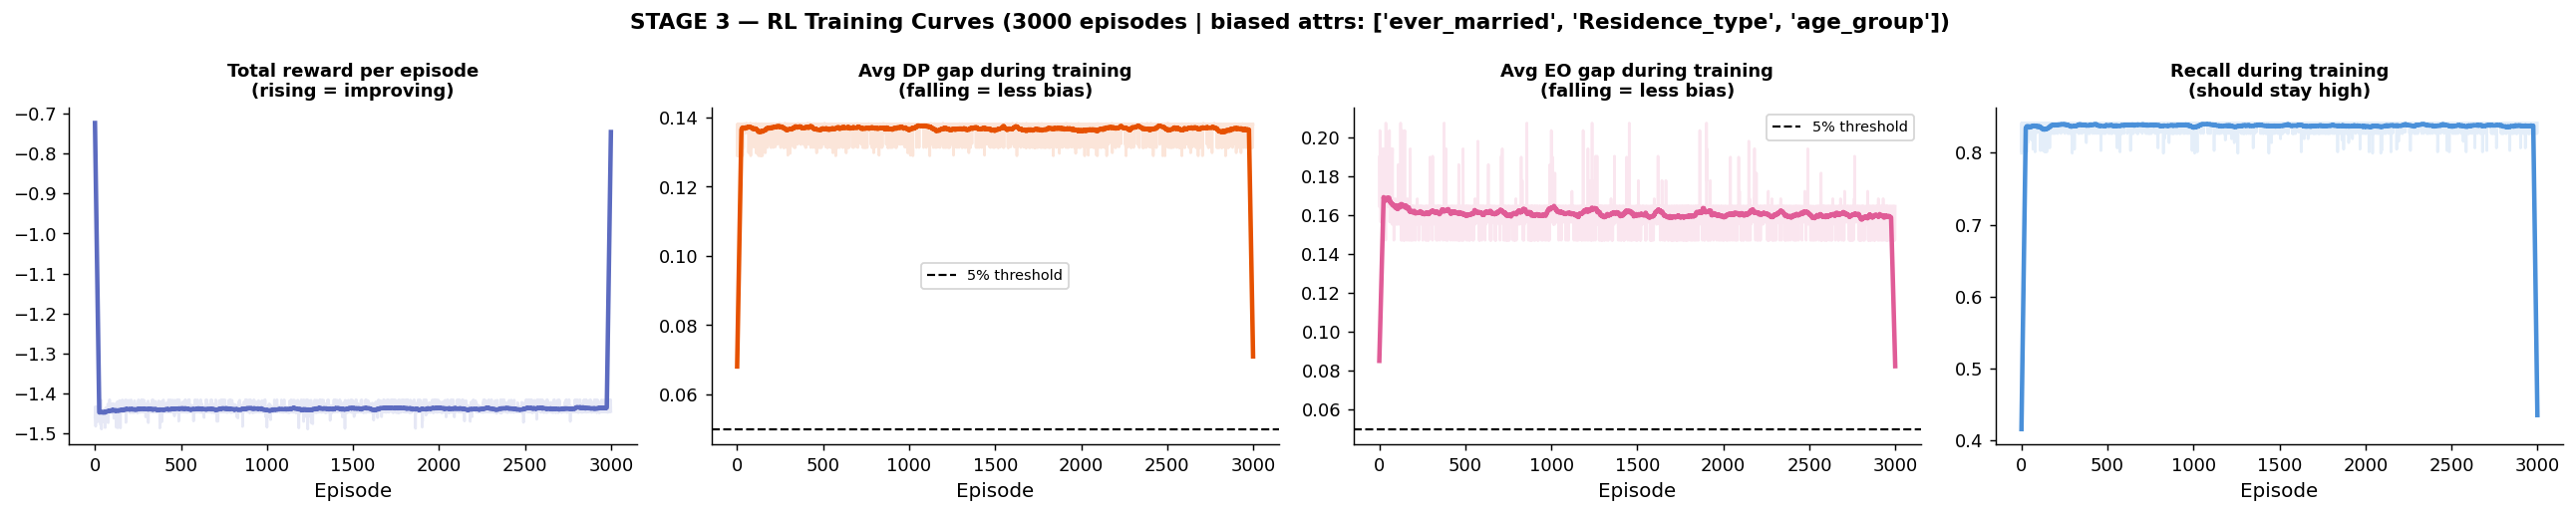

Figure 2 saved.


In [11]:
# ── Training curves (only if RL ran) ─────────────────────────────────────
if not biased_attrs:
    print('No bias detected — training curves skipped.')
else:
    def smooth(v, w=50):
        k = np.ones(w) / w
        return np.convolve(np.array(v, dtype=float), k, mode='same')

    eps = history['episode']
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'STAGE 3 — RL Training Curves ({N_EPISODES} episodes | biased attrs: {biased_attrs})',
                 fontweight='bold', fontsize=12)
    panels = [
        ('reward',  'Total reward per episode\n(rising = improving)',   '#5C6BC0'),
        ('dp_gap',  'Avg DP gap during training\n(falling = less bias)', C_BEFORE),
        ('eo_gap',  'Avg EO gap during training\n(falling = less bias)', '#E05C97'),
        ('recall',  'Recall during training\n(should stay high)',        '#4A90D9'),
    ]
    for ax, (key, title, color) in zip(axes, panels):
        raw = history[key]
        ax.plot(eps, raw, alpha=0.15, color=color)
        ax.plot(eps, smooth(raw), color=color, linewidth=2.5)
        ax.set_title(title, fontsize=10); ax.set_xlabel('Episode')
        if key in ['dp_gap', 'eo_gap']:
            ax.axhline(FAIRNESS_THRESHOLD, color='black', linestyle='--',
                       linewidth=1.2, label='5% threshold')
            ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{ASSET_DIR}/fig2_rl_training.png', bbox_inches='tight')
    plt.show()
    print('Figure 2 saved.')

In [12]:
def apply_multi_attr_thresholds(proba, attrs_dict_test, thresholds, base_thresh):
    """Apply learned thresholds to test set.

    Each patient gets the minimum threshold across all their (attr, group)
    memberships. Groups for fair attrs are not in thresholds, so they
    are skipped and only biased attrs contribute.
    A lower threshold means the patient is flagged more easily (safer).
    """
    patient_t = np.full(len(proba), base_thresh, dtype=float)
    for attr, arr in attrs_dict_test.items():
        for g in np.unique(arr):
            key = (attr, int(g))
            if key in thresholds:
                t    = float(np.clip(thresholds[key], 0.05, 0.95))
                mask = arr == g
                patient_t[mask] = np.minimum(patient_t[mask], t)
    return (proba >= patient_t).astype(int)

# Only pass biased attrs to threshold application
test_attrs_biased = {attr: split_attrs['test'][attr] for attr in biased_attrs}

if not biased_attrs:
    print('No bias — using base predictions as final.')
    y_pred_final = y_pred_base
else:
    y_pred_final = apply_multi_attr_thresholds(
        proba_test, test_attrs_biased, best_thresholds, best_thresh)
    print('RL thresholds applied to TEST set.')

recall_rl    = recall_score(y_test, y_pred_final, pos_label=1)
precision_rl = precision_score(y_test, y_pred_final, pos_label=1, zero_division=0)
f1_rl        = f1_score(y_test, y_pred_final, pos_label=1)
f2_rl        = fbeta_score(y_test, y_pred_final, beta=2.0)
gmean_rl     = gmean_score(y_test, y_pred_final)
cm_rl        = confusion_matrix(y_test, y_pred_final)
tn_rl,fp_rl,fn_rl,tp_rl = cm_rl.ravel()

# Recompute fairness for all 4 attrs after RL
rl_fairness_all = {}
for attr in PROTECTED_ATTRS:
    rl_fairness_all[attr] = compute_attr_fairness(
        y_pred    = y_pred_final,
        y_true    = y_test,
        attr_arr  = split_attrs['test'][attr],
        label_map = attr_label_maps[attr],
        attr_name = attr,
        verbose   = True
    )

print(f'\nPost-RL performance on TEST set:')
print(f'  Recall    : {recall_rl:.4f}')
print(f'  F2-stroke : {f2_rl:.4f}')
print(f'  G-Mean    : {gmean_rl:.4f}')

RL thresholds applied to TEST set.

  FAIRNESS: GENDER
  Group             Patients  Strokes  Pred rate  Detection
  --------------------------------------------------------
  Female               5,149       89      7.8%      31.5%
  Male                 3,529       68      9.9%      33.8%
  --------------------------------------------------------
  [OK] Demographic Parity gap : 2.1%  ->  FAIR  
  [OK] Equalized Odds gap     : 2.4%  ->  FAIR  

  FAIRNESS: EVER_MARRIED
  Group             Patients  Strokes  Pred rate  Detection
  --------------------------------------------------------
  No                   3,087       19      2.5%      31.6%
  Yes                  5,591      138     12.0%      32.6%
  --------------------------------------------------------
  [!!] Demographic Parity gap : 9.6%  ->  BIASED
       'Yes' predicted stroke 9.6% more often
  [OK] Equalized Odds gap     : 1.0%  ->  FAIR  

  FAIRNESS: RESIDENCE_TYPE
  Group             Patients  Strokes  Pred rate  Detecti

## STAGE 4 — Evaluation Dashboard

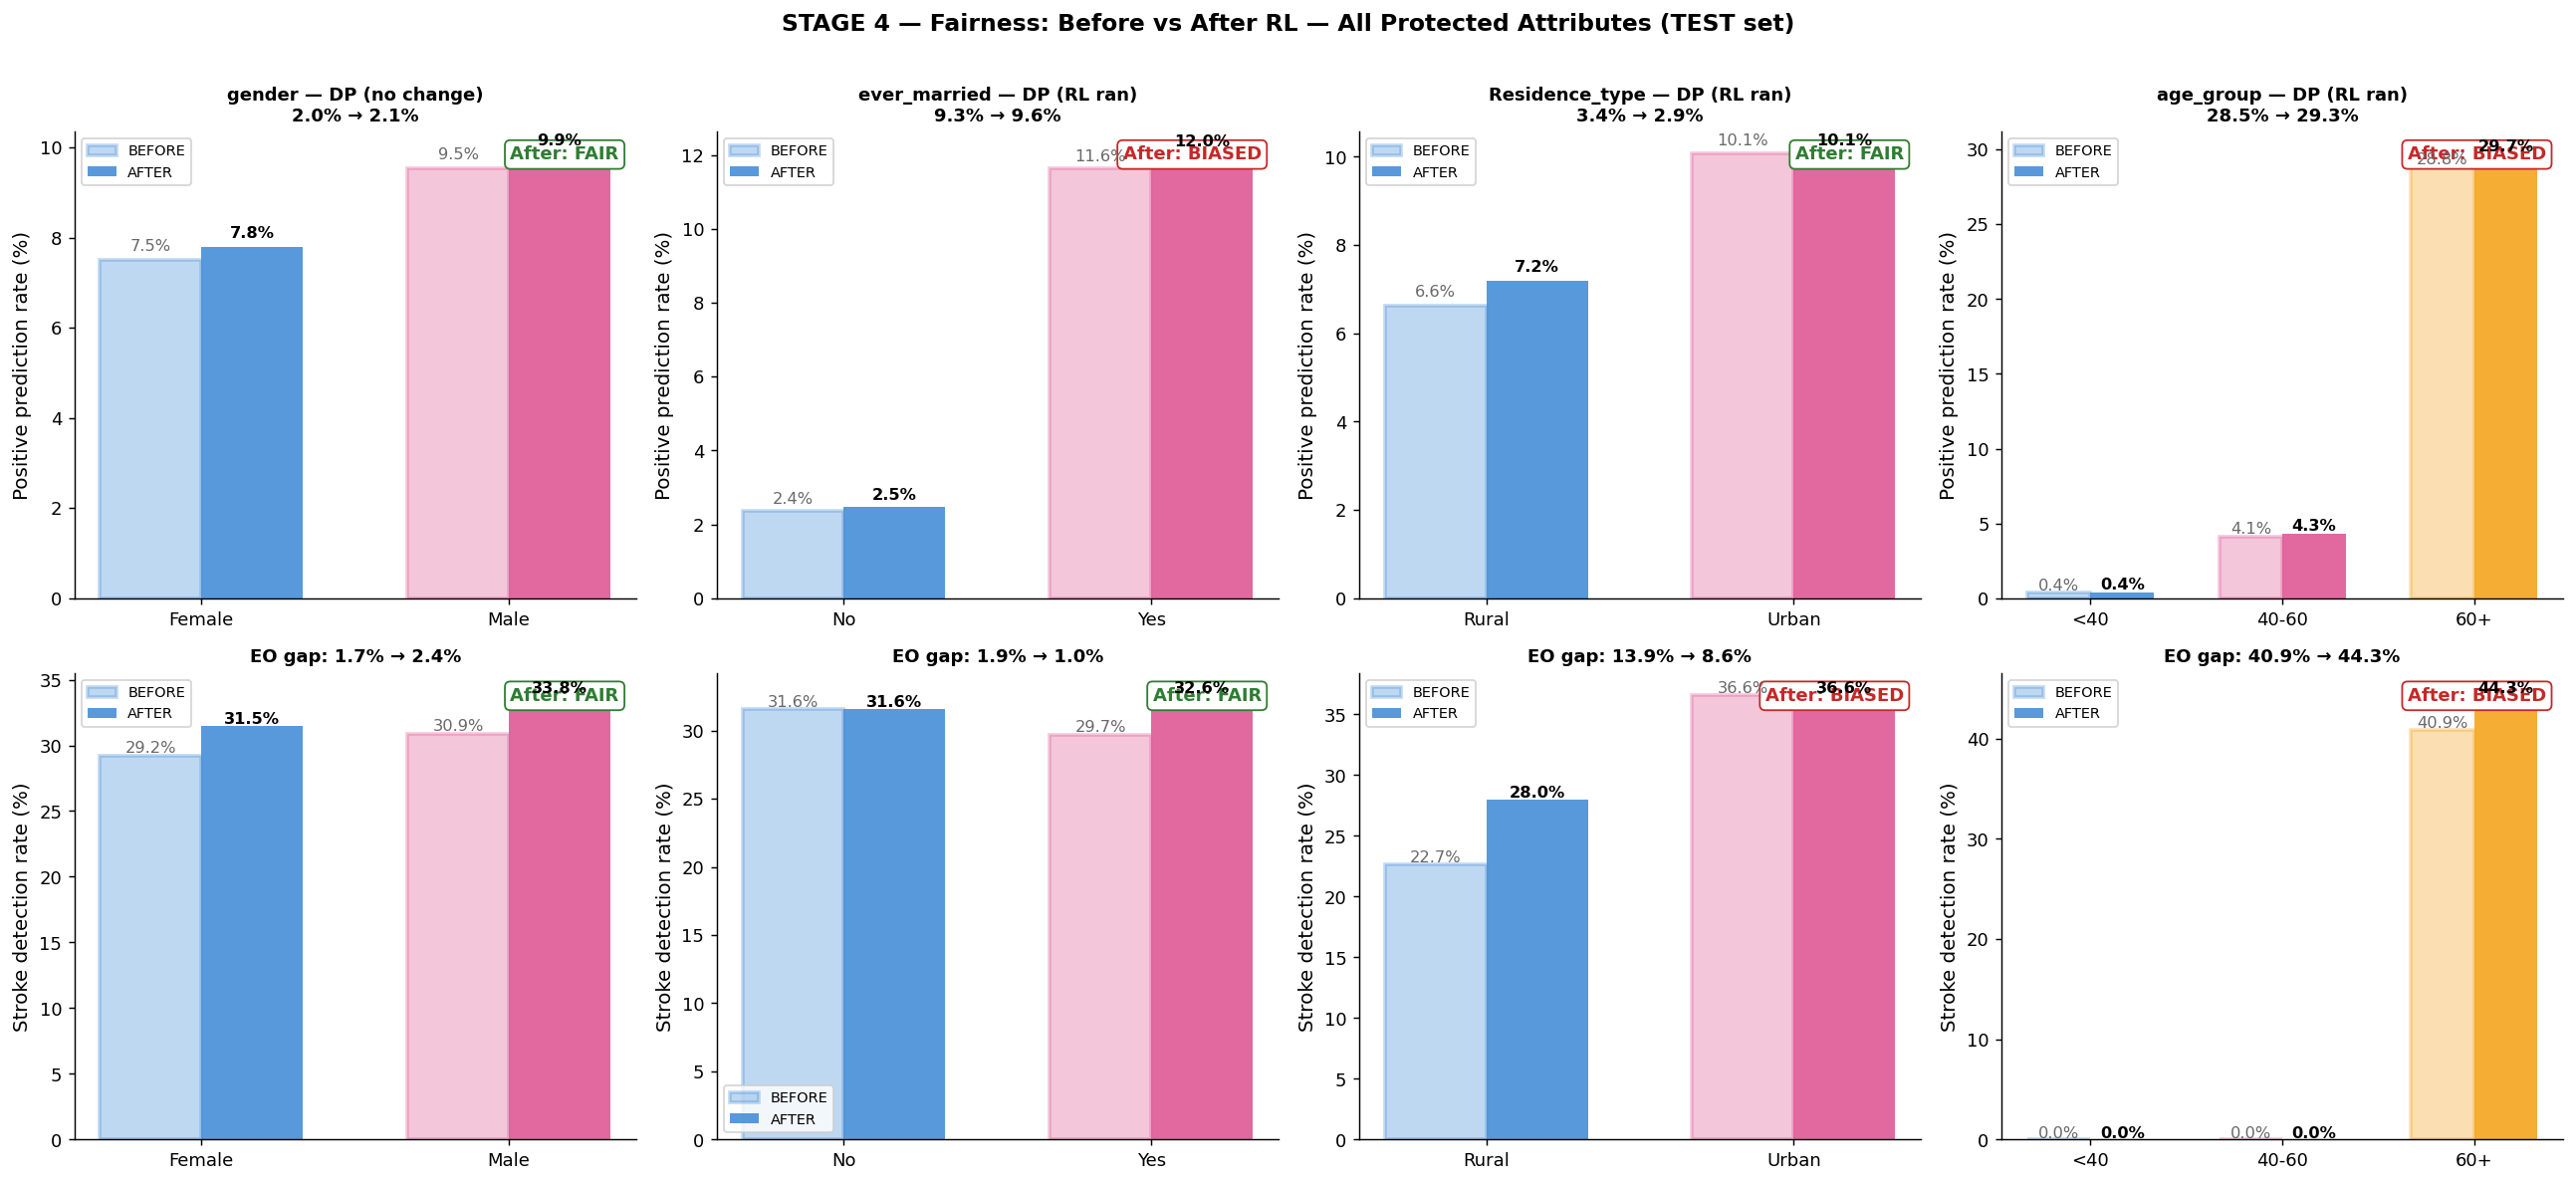

Figure 3 saved.


In [13]:
# ── Figure 3: Per-attribute fairness before vs after ──────────────────────
fig, axes = plt.subplots(2, n_attrs, figsize=(5*n_attrs, 9))
fig.suptitle('STAGE 4 — Fairness: Before vs After RL — All Protected Attributes (TEST set)',
             fontweight='bold', fontsize=13, y=1.01)

w = 0.33
for col, attr in enumerate(PROTECTED_ATTRS):
    rb     = base_fairness_all[attr]
    rr     = rl_fairness_all[attr]
    labels = list(rb['stats'].keys())
    x      = np.arange(len(labels))
    colors = GROUP_COLORS[:len(labels)]
    was_biased = attr in biased_attrs

    # Row 0: DP
    ax_dp  = axes[0, col]
    dp_b   = [rb['stats'][g]['pos_rate']*100 for g in labels]
    dp_r   = [rr['stats'][g]['pos_rate']*100 for g in labels]
    ax_dp.bar(x-w/2, dp_b, w, label='BEFORE', color=colors, alpha=0.35, edgecolor=colors, linewidth=2)
    ax_dp.bar(x+w/2, dp_r, w, label='AFTER',  color=colors, alpha=0.92)
    vc = C_FAIR if rr['dp_fair'] else C_BIASED
    tag = 'FAIR' if rr['dp_fair'] else 'BIASED'
    rl_note = '(RL ran)' if was_biased else '(no change)'
    ax_dp.set_title(f'{attr} — DP {rl_note}\n{rb["dp_gap"]:.1%} → {rr["dp_gap"]:.1%}', fontsize=10)
    ax_dp.set_ylabel('Positive prediction rate (%)')
    ax_dp.set_xticks(x); ax_dp.set_xticklabels(labels)
    ax_dp.legend(fontsize=8)
    ax_dp.text(0.97, 0.97, f'After: {tag}', transform=ax_dp.transAxes,
               fontsize=10, fontweight='bold', color=vc, ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=vc))
    for i, (bv, rv) in enumerate(zip(dp_b, dp_r)):
        ax_dp.text(i-w/2, bv+0.2, f'{bv:.1f}%', ha='center', fontsize=9, color='dimgrey')
        ax_dp.text(i+w/2, rv+0.2, f'{rv:.1f}%', ha='center', fontsize=9, fontweight='bold')

    # Row 1: EO
    ax_eo  = axes[1, col]
    eo_b   = [rb['stats'][g]['tpr']*100 for g in labels]
    eo_r   = [rr['stats'][g]['tpr']*100 for g in labels]
    ax_eo.bar(x-w/2, eo_b, w, label='BEFORE', color=colors, alpha=0.35, edgecolor=colors, linewidth=2)
    ax_eo.bar(x+w/2, eo_r, w, label='AFTER',  color=colors, alpha=0.92)
    vc2 = C_FAIR if rr['eo_fair'] else C_BIASED
    tag2 = 'FAIR' if rr['eo_fair'] else 'BIASED'
    ax_eo.set_title(f'EO gap: {rb["eo_gap"]:.1%} → {rr["eo_gap"]:.1%}', fontsize=10)
    ax_eo.set_ylabel('Stroke detection rate (%)')
    ax_eo.set_xticks(x); ax_eo.set_xticklabels(labels)
    ax_eo.legend(fontsize=8)
    ax_eo.text(0.97, 0.97, f'After: {tag2}', transform=ax_eo.transAxes,
               fontsize=10, fontweight='bold', color=vc2, ha='right', va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=vc2))
    for i, (bv, rv) in enumerate(zip(eo_b, eo_r)):
        ax_eo.text(i-w/2, bv+0.2, f'{bv:.1f}%', ha='center', fontsize=9, color='dimgrey')
        ax_eo.text(i+w/2, rv+0.2, f'{rv:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{ASSET_DIR}/fig3_fairness_before_after.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

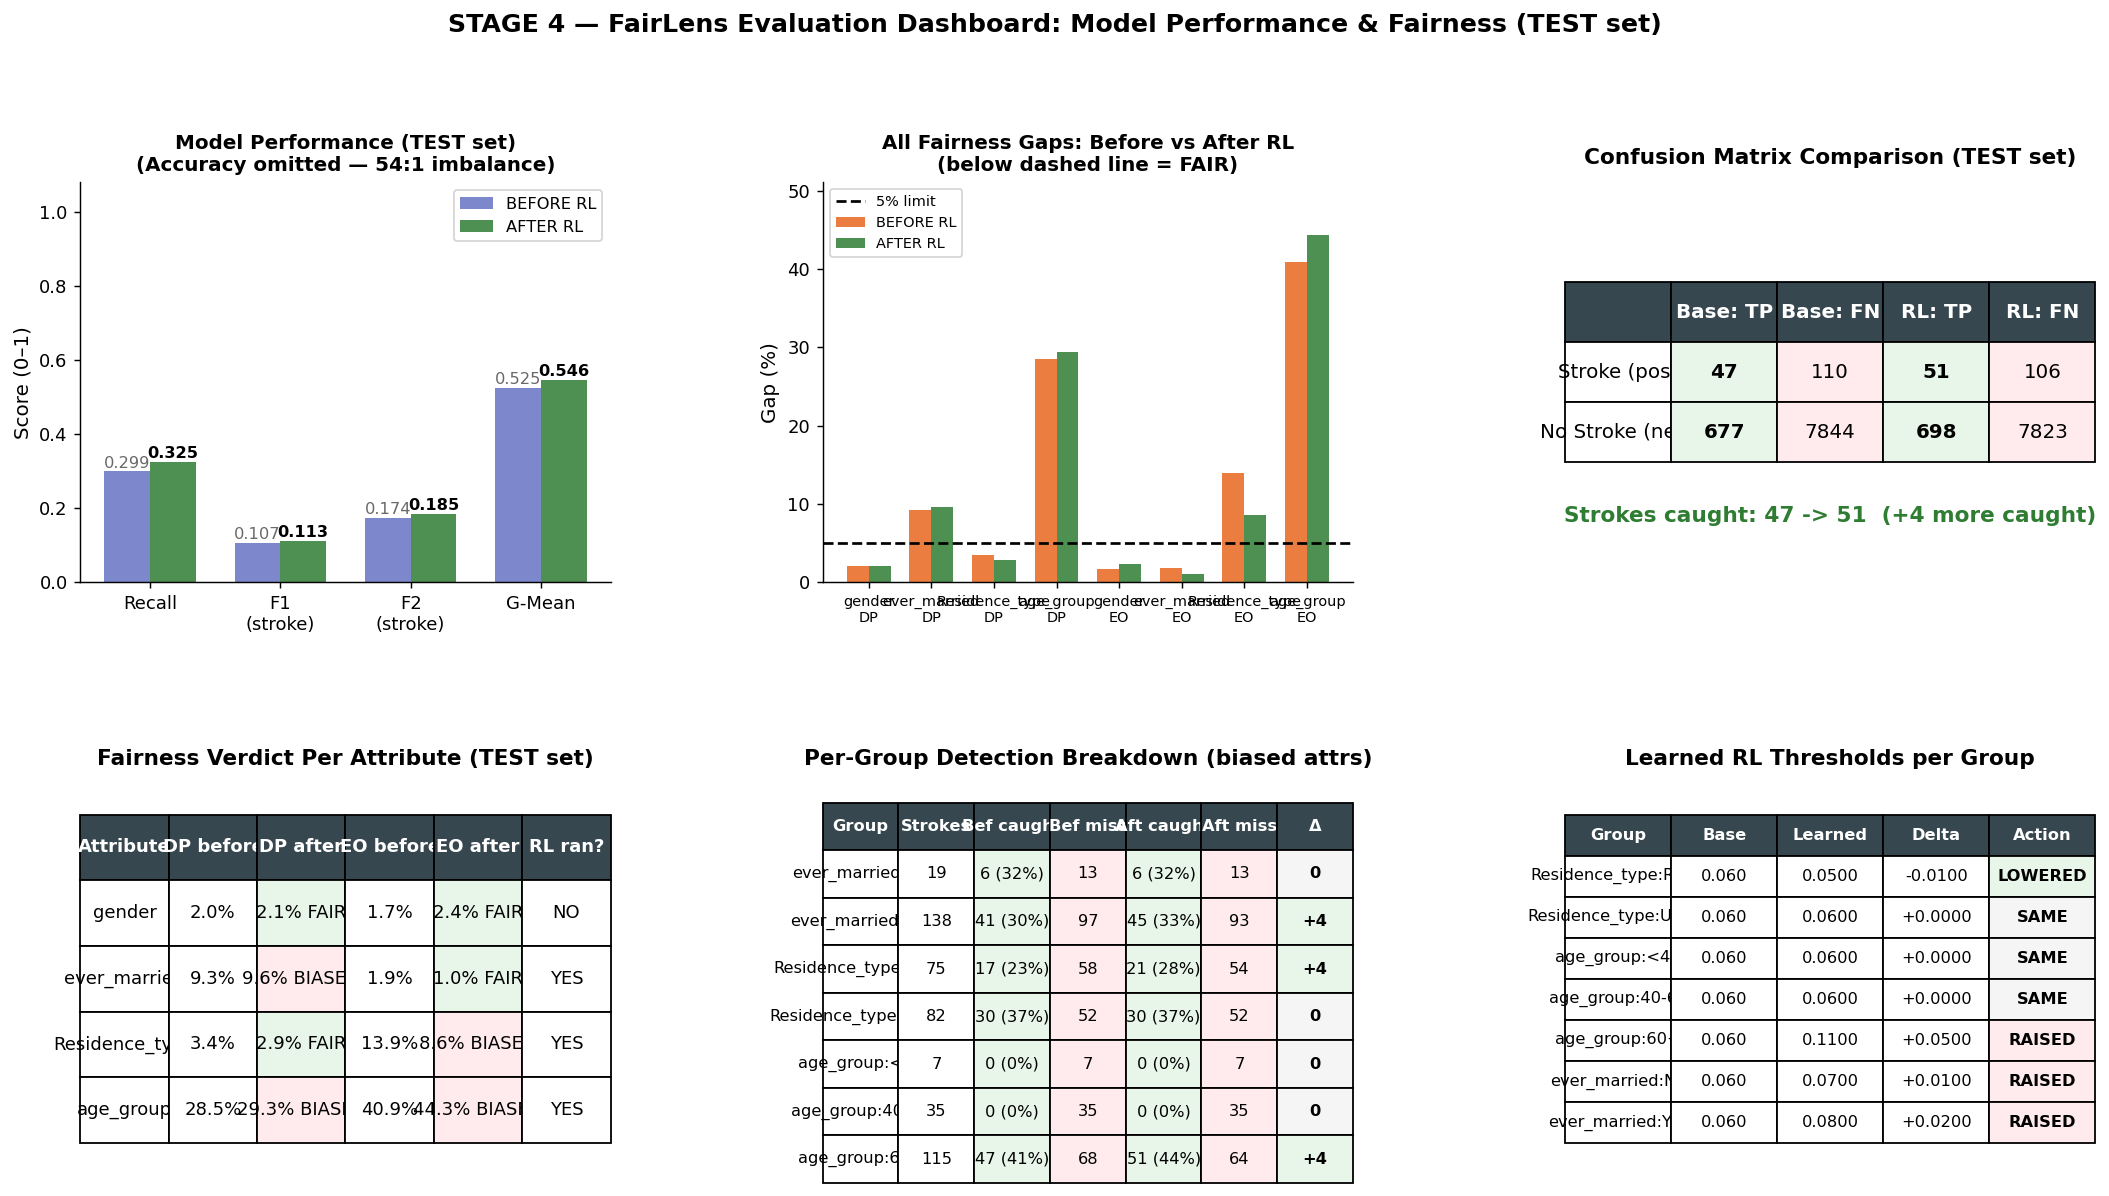

Figure 4 saved.


In [14]:
# ── Figure 4: Performance metrics + fairness gap summary ─────────────────
fig = plt.figure(figsize=(20, 10))
fig.suptitle('STAGE 4 — FairLens Evaluation Dashboard: Model Performance & Fairness (TEST set)',
             fontweight='bold', fontsize=14, y=1.01)
gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)
ax1 = fig.add_subplot(gs_fig[0,0])
ax2 = fig.add_subplot(gs_fig[0,1])
ax3 = fig.add_subplot(gs_fig[0,2])
ax4 = fig.add_subplot(gs_fig[1,0])
ax5 = fig.add_subplot(gs_fig[1,1])
ax6 = fig.add_subplot(gs_fig[1,2])

ww = 0.35

# Panel 1: Overall performance metrics
mnames = ['Recall', 'F1\n(stroke)', 'F2\n(stroke)', 'G-Mean']
mbase  = [recall_base, f1_base, f2_base, gmean_base]
mrl    = [recall_rl,   f1_rl,   f2_rl,   gmean_rl]
xm     = np.arange(len(mnames))
ax1.bar(xm-ww/2, mbase, ww, label='BEFORE RL', color='#5C6BC0', alpha=0.80)
ax1.bar(xm+ww/2, mrl,   ww, label='AFTER RL',  color=C_AFTER,  alpha=0.85)
ax1.set_title('Model Performance (TEST set)\n(Accuracy omitted — 54:1 imbalance)', fontsize=11)
ax1.set_ylabel('Score (0–1)'); ax1.set_xticks(xm); ax1.set_xticklabels(mnames)
ax1.set_ylim(0, 1.08); ax1.legend(fontsize=9)
for i, (bv, rv) in enumerate(zip(mbase, mrl)):
    ax1.text(i-ww/2, bv+0.01, f'{bv:.3f}', ha='center', fontsize=9, color='dimgrey')
    ax1.text(i+ww/2, rv+0.01, f'{rv:.3f}', ha='center', fontsize=9, fontweight='bold')

# Panel 2: Fairness gap summary — all attrs
gap_labels = [f"{a}\nDP" for a in PROTECTED_ATTRS] + [f"{a}\nEO" for a in PROTECTED_ATTRS]
gaps_b     = ([base_fairness_all[a]['dp_gap']*100 for a in PROTECTED_ATTRS] +
              [base_fairness_all[a]['eo_gap']*100 for a in PROTECTED_ATTRS])
gaps_r     = ([rl_fairness_all[a]['dp_gap']*100   for a in PROTECTED_ATTRS] +
              [rl_fairness_all[a]['eo_gap']*100   for a in PROTECTED_ATTRS])
xg = np.arange(len(gap_labels))
ax2.bar(xg-ww/2, gaps_b, ww, label='BEFORE RL', color=C_BEFORE, alpha=0.75)
ax2.bar(xg+ww/2, gaps_r, ww, label='AFTER RL',  color=C_AFTER,  alpha=0.85)
ax2.axhline(5.0, color='black', linestyle='--', linewidth=1.5, label='5% limit')
ax2.set_title('All Fairness Gaps: Before vs After RL\n(below dashed line = FAIR)', fontsize=11)
ax2.set_ylabel('Gap (%)')
ax2.set_xticks(xg); ax2.set_xticklabels(gap_labels, fontsize=8)
ax2.legend(fontsize=8)
if gaps_b: ax2.set_ylim(0, max(max(gaps_b), 6) * 1.25)

# Panel 3: Confusion matrix comparison
ax3.axis('off')
cm_rows = [['','Base: TP','Base: FN','RL: TP','RL: FN'],
           ['Stroke (pos)', str(tp_b), str(fn_b), str(tp_rl), str(fn_rl)],
           ['No Stroke (neg)', str(fp_b), str(tn_b), str(fp_rl), str(tn_rl)]]
tbl2 = ax3.table(cellText=cm_rows[1:], colLabels=cm_rows[0],
                 cellLoc='center', loc='center', bbox=[0,0.3,1,0.45])
tbl2.auto_set_font_size(False); tbl2.set_fontsize(11)
for (r,c), cell in tbl2.get_celld().items():
    if r==0: cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
    elif c in [1,3] and r>0: cell.set_facecolor('#E8F5E9'); cell.set_text_props(fontweight='bold')
    elif c in [2,4] and r>0: cell.set_facecolor('#FFEBEE')
diff_caught = tp_rl - tp_b
diff_str = (f'+{diff_caught} more caught' if diff_caught > 0
            else (f'{diff_caught} fewer' if diff_caught < 0 else 'same'))
ax3.text(0.5, 0.15, f'Strokes caught: {tp_b} -> {tp_rl}  ({diff_str})',
         transform=ax3.transAxes, ha='center', fontsize=12, fontweight='bold',
         color=C_AFTER if diff_caught >= 0 else C_BIASED)
ax3.set_title('Confusion Matrix Comparison (TEST set)', fontweight='bold', pad=10)

# Panel 4: Fairness verdict grid (all attrs × DP/EO)
ax4.axis('off')
vrows = []
for attr in PROTECTED_ATTRS:
    rb = base_fairness_all[attr]; rr = rl_fairness_all[attr]
    ran = 'YES' if attr in biased_attrs else 'NO'
    vrows.append([
        attr,
        f"{rb['dp_gap']:.1%}",
        f"{rr['dp_gap']:.1%} {'FAIR' if rr['dp_fair'] else 'BIASED'}",
        f"{rb['eo_gap']:.1%}",
        f"{rr['eo_gap']:.1%} {'FAIR' if rr['eo_fair'] else 'BIASED'}",
        ran
    ])
vcols = ['Attribute','DP before','DP after','EO before','EO after','RL ran?']
vtbl  = ax4.table(cellText=vrows, colLabels=vcols,
                  cellLoc='center', loc='center', bbox=[0,0.1,1,0.82])
vtbl.auto_set_font_size(False); vtbl.set_fontsize(10)
for (r,c), cell in vtbl.get_celld().items():
    if r==0: cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
    elif r>0 and c in [2,4]:
        txt = cell.get_text().get_text()
        if 'FAIR' in txt: cell.set_facecolor('#E8F5E9')
        elif 'BIASED' in txt: cell.set_facecolor('#FFEBEE')
ax4.set_title('Fairness Verdict Per Attribute (TEST set)', fontweight='bold', pad=10)

# Panel 5: Per-group stroke detection breakdown (biased attrs only)
ax5.axis('off')
prows = []
for attr in biased_attrs:
    lmap = attr_label_maps[attr]
    for g_code in np.unique(split_attrs['test'][attr]):
        lbl  = lmap.get(int(g_code), str(g_code))
        sb   = base_fairness_all[attr]['stats'][lbl]
        sr   = rl_fairness_all[attr]['stats'][lbl]
        tot  = sb['n_strokes']
        tp_bg = int(sb['tpr']*tot); fn_bg = tot - tp_bg
        tp_rg = int(sr['tpr']*tot); fn_rg = tot - tp_rg
        diff  = tp_rg - tp_bg
        prows.append([f"{attr}:{lbl}", str(tot),
                      f"{tp_bg} ({sb['tpr']:.0%})", str(fn_bg),
                      f"{tp_rg} ({sr['tpr']:.0%})", str(fn_rg),
                      f"+{diff}" if diff>0 else str(diff)])
if prows:
    pcols = ['Group','Strokes','Bef caught','Bef miss','Aft caught','Aft miss','Δ']
    ptbl  = ax5.table(cellText=prows, colLabels=pcols,
                      cellLoc='center', loc='center', bbox=[0,0,1,0.95])
    ptbl.auto_set_font_size(False); ptbl.set_fontsize(9)
    for (r,c), cell in ptbl.get_celld().items():
        if r==0: cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
        elif c in [2,4] and r>0: cell.set_facecolor('#E8F5E9')
        elif c in [3,5] and r>0: cell.set_facecolor('#FFEBEE')
        elif c==6 and r>0:
            val = cell.get_text().get_text()
            cell.set_facecolor('#E8F5E9' if val.startswith('+') else
                               '#FFEBEE' if val.startswith('-') else '#F5F5F5')
            cell.set_text_props(fontweight='bold')
else:
    ax5.text(0.5, 0.5, 'No biased attributes — no per-group breakdown.',
             ha='center', va='center', transform=ax5.transAxes)
ax5.set_title('Per-Group Detection Breakdown (biased attrs)', fontweight='bold', pad=10)

# Panel 6: RL threshold summary
ax6.axis('off')
if best_thresholds:
    thresh_rows = []
    for (attr, g_code), t in sorted(best_thresholds.items()):
        lbl = attr_label_maps[attr].get(int(g_code), str(g_code))
        d   = t - best_thresh
        thresh_rows.append([f"{attr}:{lbl}",
                            f"{best_thresh:.3f}",
                            f"{t:.4f}",
                            f"{d:+.4f}",
                            'RAISED' if d>0.001 else 'LOWERED' if d<-0.001 else 'SAME'])
    tcols = ['Group','Base','Learned','Delta','Action']
    ttbl  = ax6.table(cellText=thresh_rows, colLabels=tcols,
                      cellLoc='center', loc='center', bbox=[0,0.1,1,0.82])
    ttbl.auto_set_font_size(False); ttbl.set_fontsize(9)
    for (r,c), cell in ttbl.get_celld().items():
        if r==0: cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
        elif c==4 and r>0:
            val = cell.get_text().get_text()
            cell.set_facecolor('#FFEBEE' if val=='RAISED' else '#E8F5E9' if val=='LOWERED' else '#F5F5F5')
            cell.set_text_props(fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'No RL ran — all attributes were fair.', ha='center', va='center',
             transform=ax6.transAxes, fontsize=12)
ax6.set_title('Learned RL Thresholds per Group', fontweight='bold', pad=10)

plt.savefig(f'{ASSET_DIR}/fig4_evaluation_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figure 4 saved.')

In [15]:
# ── Final plain-English report ────────────────────────────────────────────
sep  = '=' * 70
sep2 = '-' * 70

def verdict_tag(delta, lower_is_better=True):
    if lower_is_better:
        return 'IMPROVED' if delta<-0.001 else ('WORSENED' if delta>0.001 else 'UNCHANGED')
    else:
        return 'IMPROVED' if delta>0.001  else ('WORSENED' if delta<-0.001 else 'UNCHANGED')

print(sep)
print('  FAIRLENS — FINAL EVALUATION REPORT')
print(sep)

print('\n  MODEL OVERVIEW')
print(sep2)
print(f'  Classifier   : Calibrated Random Forest (pre-trained, not retrained here)')
print(f'  TEST set     : {len(y_test):,} patients  |  real strokes: {y_test.sum()}')
print(f'  TRAIN set    : {len(y_train):,} patients  (pre-SMOTE, used by RL env)')
print(f'  VAL set      : {len(y_val):,} patients  (recall floor = {f'{recall_floor:.4f}' if biased_attrs else 'N/A'})')
print(f'  Imbalance    : {imbalance_ratio:.1f}:1  -> primary metrics: Recall, F2, G-Mean (NOT accuracy)')
print(f'  Threshold    : {best_thresh:.3f}  (F2-tuned on VAL in Notebook 1)')
print(f'  ROC-AUC      : {roc_base:.4f}  (unchanged — base model not retrained)')
print(f'  RL episodes  : {N_EPISODES}')
print(f'  Biased attrs : {biased_attrs if biased_attrs else "none"}')
print(f'  Fair attrs   : {[a for a in PROTECTED_ATTRS if a not in biased_attrs]}')

print('\n' + sep)
print('  SECTION 1 — BIAS DETECTION RESULTS (TEST SET)')
print(sep)
print(f"  {'Attribute':<22} {'DP before':>10} {'DP after':>10} {'EO before':>10} {'EO after':>10} {'RL ran':>7}")
print('  ' + '-' * 68)
for attr in PROTECTED_ATTRS:
    rb = base_fairness_all[attr]; rr = rl_fairness_all[attr]
    ran = 'YES' if attr in biased_attrs else 'NO'
    print(f"  {attr:<22} {rb['dp_gap']:>9.1%} {rr['dp_gap']:>10.1%} "
          f"{rb['eo_gap']:>9.1%} {rr['eo_gap']:>10.1%} {ran:>7}")

print('\n' + sep)
print('  SECTION 2 — WHAT THE RL AGENT DID')
print(sep)
if biased_attrs:
    print(f'\n  RL trained on TRAIN split ({len(y_train):,} real pre-SMOTE patients).')
    print(f'  VAL split set recall floor = {recall_floor:.4f} — agent penalised for going below.')
    print(f'  One threshold per (attr, group) pair, adjusted independently.')
    print(f'  At test time: each patient gets the MINIMUM threshold across all their groups.')
    print()
    for (attr, g_code), t in sorted(best_thresholds.items()):
        lbl = attr_label_maps[attr].get(int(g_code), str(g_code))
        d   = t - best_thresh
        print(f'  {attr}:{lbl:<20}  {best_thresh:.3f} -> {t:.4f}  ({d:+.4f})', end='  ')
        if   d >  0.001: print('RAISED  — needs more confidence to flag (less over-prediction)')
        elif d < -0.001: print('LOWERED — flags more easily (catches more real strokes)')
        else:            print('UNCHANGED')
else:
    print('\n  No bias detected — RL agent did not run.')

print('\n' + sep)
print('  SECTION 3 — PERFORMANCE AFTER CORRECTION (TEST SET)')
print(sep)
print(f"\n  {'Metric':<16} {'Before RL':>12} {'After RL':>12} {'Change':>10} {'Verdict':>12}")
print('  ' + '-' * 64)
for name, bv, rv in [
    ('Recall',    recall_base,    recall_rl),
    ('F1-stroke', f1_base,        f1_rl),
    ('F2-stroke', f2_base,        f2_rl),
    ('G-Mean',    gmean_base,     gmean_rl),
]:
    d = rv - bv
    print(f"  {name:<16} {bv:>12.4f} {rv:>12.4f} {d:>+10.4f} {verdict_tag(d, lower_is_better=False):>12}")
print(f"  {'ROC-AUC':<16} {roc_base:>12.4f} {roc_base:>12.4f} {'0.0000':>10} {'UNCHANGED':>12}")

diff_caught = tp_rl - tp_b
print(f'\n  Strokes caught:')
print(f'    Before RL : {tp_b} of {tp_b+fn_b}  ({recall_base:.1%})')
print(f'    After  RL : {tp_rl} of {tp_rl+fn_rl}  ({recall_rl:.1%})')
if diff_caught > 0:
    print(f'    Result    : {diff_caught} MORE strokes caught after RL correction')
elif diff_caught < 0:
    print(f'    Result    : {abs(diff_caught)} fewer strokes (fairness trade-off applied)')
else:
    print('    Result    : Same number of strokes caught')

print('\n' + sep)
print('  FAIRLENS EVALUATION COMPLETE')
print(sep2)
print(f'  Figures saved to: {ASSET_DIR}/')
print('    fig1_bias_detection.png       <- Stage 2 all-attribute bias detection')
print('    fig2_rl_training.png          <- Stage 3 RL training curves')
print('    fig3_fairness_before_after.png <- Stage 4 per-attribute before/after')
print('    fig4_evaluation_dashboard.png <- Stage 4 full dashboard')
print(sep)


  FAIRLENS — FINAL EVALUATION REPORT

  MODEL OVERVIEW
----------------------------------------------------------------------
  Classifier   : Calibrated Random Forest (pre-trained, not retrained here)
  TEST set     : 8,678 patients  |  real strokes: 157
  TRAIN set    : 30,372 patients  (pre-SMOTE, used by RL env)
  VAL set      : 4,339 patients  (recall floor = 0.3205)
  Imbalance    : 54.4:1  -> primary metrics: Recall, F2, G-Mean (NOT accuracy)
  Threshold    : 0.060  (F2-tuned on VAL in Notebook 1)
  ROC-AUC      : 0.7999  (unchanged — base model not retrained)
  RL episodes  : 3000
  Biased attrs : ['ever_married', 'Residence_type', 'age_group']
  Fair attrs   : ['gender']

  SECTION 1 — BIAS DETECTION RESULTS (TEST SET)
  Attribute               DP before   DP after  EO before   EO after  RL ran
  --------------------------------------------------------------------
  gender                      2.0%       2.1%      1.7%       2.4%      NO
  ever_married                9.3%     